# 🔬 超声视频 VLM 筛选器 - 测试 Notebook

逐步测试 `video_filter_vlm.py` 的各个阶段

In [1]:
# Cell 1: 安装依赖 (首次运行取消注释)
# !pip install torch torchvision transformers accelerate qwen-vl-utils opencv-python numpy Pillow matplotlib openai

In [2]:
# Cell 2: 导入并加载模型
from video_filter_vlm import load_model, sample_frames, run_stage1, run_stage2, parse_json_from_text
import json
from pathlib import Path

model, processor, device = load_model()

/Users/I761836/Documents/Semester3/Guided Research/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Apple Silicon MPS
加载 Qwen2-VL-2B-Instruct ...


Loading weights: 100%|██████████| 729/729 [00:02<00:00, 247.75it/s]


✅ 模型加载完成!


📹 adJepggTLd4
   时长: 170.0s (2.8min) | FPS: 30 | 总帧: 5095
   ✅ 采样 10 帧


/var/folders/rw/wshxx7sj7sd93lhr6hgwtcm80000gn/T/ipykernel_92618/1036613709.py:14: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rw/wshxx7sj7sd93lhr6hgwtcm80000gn/T/ipykernel_92618/1036613709.py:14: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rw/wshxx7sj7sd93lhr6hgwtcm80000gn/T/ipykernel_92618/1036613709.py:14: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/I761836/Documents/Semester3/Guided Research/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/I761836/Documents/Semester3/Guided Research/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED I

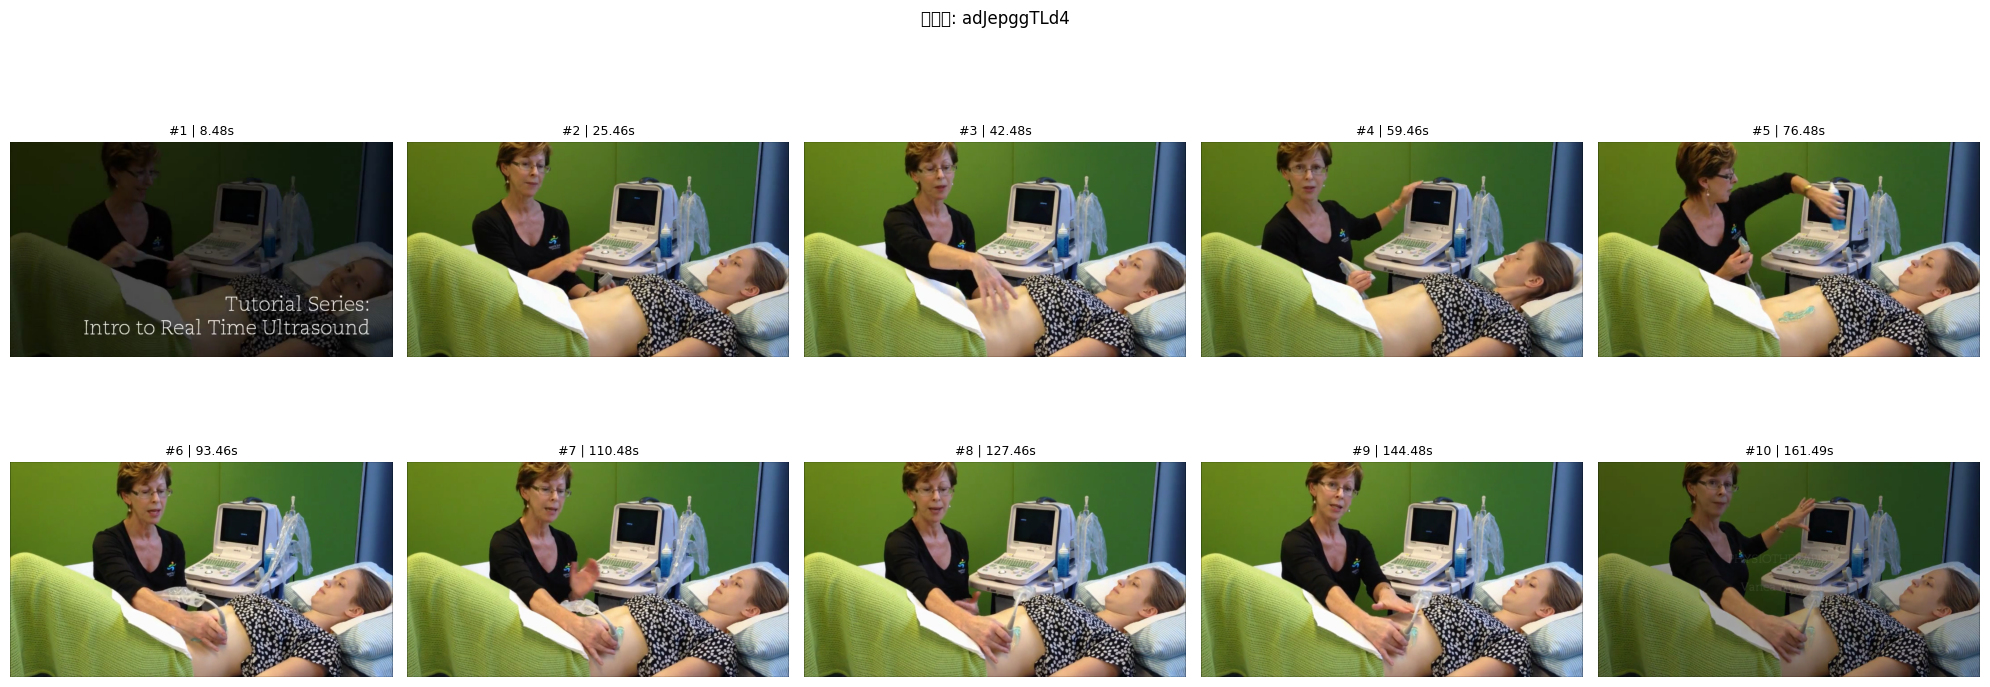

In [3]:
# Cell 3: 采样视频帧并可视化
import matplotlib.pyplot as plt

VIDEO_PATH = "UltrasoundCrawler_KeyCode_20260323_v2/output/20260502_152417_youtube/media/organ_system_lecture/adJepggTLd4.mp4"
frames, video_info = sample_frames(VIDEO_PATH, num_frames=10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, f in enumerate(frames):
    ax = axes[i//5][i%5]
    ax.imshow(f['image'])
    ax.set_title(f"#{i+1} | {f['timestamp']}s", fontsize=9)
    ax.axis('off')
plt.suptitle(f"采样帧: {Path(VIDEO_PATH).stem}")
plt.tight_layout()
plt.show()

In [4]:
# Cell 4: Stage 1 - Qwen2-VL 逐帧分析 (约30-80秒)
frame_results = run_stage1(model, processor, device, frames)

当前Prompt (前100字):
分析这张医学影像图片。请参考示例格式回答。

示例1 - 如果是超声画面：
{"帧类型":"超声画面","超声模态":"B超","标注程度":"仅机器参数","有人脸":false,"有文字覆盖":f ...


🔍 Stage 1: Qwen2-VL 逐帧分析
  [ 1/10] 7.4s | 讲课画面 | 一位医生面对镜头讲解超声扫查技巧
  [ 2/10] 5.8s | 医学影像 | 一位医生正在为一位女性进行腹部B超检查，患者躺在检查床上，医生正在操作
  [ 3/10] 5.8s | 医学影像 | 一位医生正在为一位女性进行腹部B超检查，医生的手正在触摸患者的腹部，检
  [ 4/10] 5.0s | 讲课画面 | 一位医生面对镜头讲解超声扫查技巧
  [ 5/10] 7.4s | 医学影像 | 一位医生正在为一位女性进行腹部超声检查，医生正在操作超声设备，患者躺在
  [ 6/10] 5.1s | 讲课画面 | 一位医生面对镜头讲解超声扫查技巧
  [ 7/10] 5.0s | 讲课画面 | 一位医生面对镜头讲解超声扫查技巧
  [ 8/10] 5.0s | 讲课画面 | 一位医生面对镜头讲解超声扫查技巧
  [ 9/10] 6.1s | 讲课画面 | 一位医生面对镜头讲解超声扫查技巧
  [10/10] 6.2s | 医学影像 | 一位孕妇正在进行超声检查，医生正在操作超声设备。

⏱️  Stage 1 完成! 总耗时: 59.2s (平均 5.9s/帧)


In [5]:
# Cell 5: 查看 Stage 1 结果
print("Stage 1 结果:")
print("=" * 60)
for i, r in enumerate(frame_results):
    clean = {k: v for k, v in r.items() if k != '_raw_output'}
    print(f"\n帧 {i+1} (t={r.get('timestamp','?')}s):")
    print(json.dumps(clean, ensure_ascii=False, indent=2))

print("\n\n📊 统计:")
types = [r.get('帧类型', '?') for r in frame_results]
for t in set(types):
    print(f"  {t}: {types.count(t)}/{len(types)}")

Stage 1 结果:

帧 1 (t=8.48s):
{
  "帧类型": "讲课画面",
  "超声模态": "无",
  "标注程度": "无标注",
  "有人脸": true,
  "有文字覆盖": false,
  "解剖部位": null,
  "置信度": 0.9,
  "简要描述": "一位医生面对镜头讲解超声扫查技巧",
  "timestamp": 8.48
}

帧 2 (t=25.46s):
{
  "帧类型": "医学影像",
  "超声模态": "B超",
  "标注程度": "仅机器参数",
  "有人脸": false,
  "有文字覆盖": false,
  "解剖部位": "腹部",
  "置信度": 0.9,
  "简要描述": "一位医生正在为一位女性进行腹部B超检查，患者躺在检查床上，医生正在操作B超设备。",
  "timestamp": 25.46
}

帧 3 (t=42.48s):
{
  "帧类型": "医学影像",
  "超声模态": "B超",
  "标注程度": "仅机器参数",
  "有人脸": false,
  "有文字覆盖": false,
  "解剖部位": "腹部",
  "置信度": 0.9,
  "简要描述": "一位医生正在为一位女性进行腹部B超检查，医生的手正在触摸患者的腹部，检查部位为腹部。",
  "timestamp": 42.48
}

帧 4 (t=59.46s):
{
  "帧类型": "讲课画面",
  "超声模态": "无",
  "标注程度": "无标注",
  "有人脸": true,
  "有文字覆盖": false,
  "解剖部位": null,
  "置信度": 0.9,
  "简要描述": "一位医生面对镜头讲解超声扫查技巧",
  "timestamp": 59.46
}

帧 5 (t=76.48s):
{
  "帧类型": "医学影像",
  "超声模态": "B超",
  "标注程度": "仅机器参数",
  "有人脸": false,
  "有文字覆盖": false,
  "解剖部位": "腹部",
  "置信度": 0.9,
  "简要描述": "一位医生正在为一位女性进行腹部超声检查，医生正在操作超声设备，患者躺在检查床上，腹部贴有标记，医生正

In [6]:
# Cell 6: Stage 2 - GPT-4o-mini 综合判断
OPENAI_API_KEY = "your-openai-api-key-here"  # ⚠️ 替换为你的key

video_id = Path(VIDEO_PATH).stem
final_result = run_stage2(frame_results, video_info, video_id, OPENAI_API_KEY, provider="openai")

print("\n最终决策:")
print(json.dumps(final_result, ensure_ascii=False, indent=2))


🤖 Stage 2: GPT-4o-mini 综合判断
   耗时: 4.3s
   Token使用: 1514 tokens

📊 综合判断结果:
{
  "视频ID": "adJepggTLd4",
  "是超声视频": true,
  "超声帧占比": 0.4,
  "主要内容": "混合内容",
  "主要模态": "B超",
  "标注程度": "仅机器参数",
  "检测到的解剖部位": [
    "腹部"
  ],
  "质量评分": 70,
  "决策": "需要去标注",
  "判断理由": "视频包含超声检查的相关帧，但标注程度较低，缺乏详细的解剖部位标注，适合进一步标注后用于AI模型训练。"
}

最终决策:
{
  "视频ID": "adJepggTLd4",
  "是超声视频": true,
  "超声帧占比": 0.4,
  "主要内容": "混合内容",
  "主要模态": "B超",
  "标注程度": "仅机器参数",
  "检测到的解剖部位": [
    "腹部"
  ],
  "质量评分": 70,
  "决策": "需要去标注",
  "判断理由": "视频包含超声检查的相关帧，但标注程度较低，缺乏详细的解剖部位标注，适合进一步标注后用于AI模型训练。"
}
